# **서비스 분석 및 전략 수립 프로젝트** 

* Dataset : eCommerce Events History in Cosmetics Shop
            (https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/data)

 이 데이터셋은 2019년 10월부터 2020년 2월까지의 약 5개월간의 화장품 온라인 상점의 고객 약 164만명의 행동데이터가 포함되어 있다. 제품 조회, 장바구니 추가, 구매 등이 20,692,840건의 데이터가 포함되어 있다. 
 위 데이터를 이용하여 EDA를 진행 후, AARRR 프레임워크 기반의 서비스 성장 분석을 진행한다.


## 0. EDA 진행   
      : EDA를 통하여 데이터의 기본 구조, 결측치와 이상치를 확인하였으며, 이를 통하여 데이터를 정제하였다. 또한 이 과정을 통하여 분석에 중한 컬럼을 확인하여 분석방향을 결정하게 되었다.  
   1. 데이터 기본      
      - 데이터 기간 : 2019.10.01 ~ 2020.02.29
      - 전체 행수 : 20,692,840건  
      - 전체 컬럼 수 : 'event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session'   
   2. 결측치 및 이상치 확인   
      (1) 결측치 : 'category_code' 20,339,246건(98.29%), 'brand' 8,757,117건 (42.32%), 'user_session' 4,598건(0.02%) → 삭제  
      (2) 이상치  
        - price : (-)값의 데이터 131건을 확인하였고, 이를 추가적으로 분석 후 데이터 오류로 확인하고 이에 대하여 삭제 처리   
        - user_session   
          a. 1개의 세션에 여러 개의 user_id가 존재하는 경우 확인 → 삭제  
          b. 유저별 세션 수 확인 : 세션 이용시간을 일반적인 업계 기준을 30분을 적용하여, 데이터분석 기간인 5개월간 이용세션 수가 7.296건(5개월간 30분단위로 접속한 최대수)을 넘는 경우, 해당 데이터 삭제       


## Ⅰ. 분석 방향  
   1. **'event_type'** : 행동 이벤트('event_type')에 있어서 'view -> cart -> purchase'와 같이 구매로 연결되는 패턴과 'cart -> remove from cart'와 같이 미구매로 이어지는 패턴을 고객별로 집계하여 특징을 도출한다.  => **구매전환율** / 퍼널 분석
   2. **'event_time', 'user_session'** : 고객별 첫 구매월을 기준으로 그룹화하여 기간 경과에 따른 사용자의 구매 관련 행동 패턴을 추적 및 파악한다. 
      (1) 고객 첫 구매 후 유지율(이탈율) 확인 => 리텐션 분석   
         - 측정방법 : 월 기준 Retention 
                    (※ 화장품 마켓에서 고객의 구매 패턴 및 주기 반영 : 블랙프라이데이 시즌시 대량 구매 등 도메인 특성 확인)
      (2) 구매 후 재구매가 이루어진 고객의 패턴 파악 (방문횟수, 활동 패턴 확인)  
         - 동일 월 기준으로 쇼핑몰에 가입한 사용자를 기준으로 코호트를 구분하여, 공통된 특성 파악 (코호트별 리텐션 파악)
  

## Ⅱ. AARRR 프레임  
   1. Acquisition(획득) : 서비스에 처음 방문한 신규 유저  
      ※ 해당 데이터셋은 2019.10월부터 2020.02월의 데이터로 2019.10월 새로 런칭한 것으로 가정을 하고 데이터 분석을 진행한다.  
      * 중요 지표  
        - 신규 유저수 : 월별 최초로 확인되는 user_id   
        - 신규 유저 비율 : 전체 유저 중 신규 비율 (2019.10월 user_id 고유값은 모두 신규 유저)
   2. **Activation(활성화)** : 고객이 방문해서 단순하게 제품을 검색 또는 보는 것에 그치는 것이 아닌 구매를 고려하게 되는 행위인 장바구니에 담는 행동(cart)까지 완료된 유저 확인  
      * 중요 지표  
        - view → cart 전환율 : cart 행동 진행 유저 / 전체 방문 유저  
        - 세션 당 평균 view 수 : 제품을 구매 전, 이 제품이 구매할 가치가 있는 지 확인하는 유저의 행동 확인  
   3. **Retention(유지)** : 화장품 구매주기 (1개월 ~ 3개월, 계절별 피부타입 등을 고려하려 짧게는 1개월 ~ 3개월 설정,자주 사용하는 제품의 경우, 특정 할인 기간에 대량으로 구입)를 고려한 코호트 리텐션 분석  
   4. Revenue(수익) : 구매(purcahse)에서 발생한 수익 지표  
      * 중요 지표  
        - 월별 총 매출 / 평균 구매 단가 / 유저당 구입액  
        - 구매 전환율 (cart → purchase 전환) : purchase 유저 / 전체 방문 유저  
   5. Referral (추천) : 추천코드나 바이럴로 특정 상품 링크를 통해 신규 유저 증가율 등을 통하여 확인할 수 있으나, 이 데이터셋에는 추천과 관련된 데이터(추천코드, 유입경로 등)가 존재하지 않아 분석에서 제외한다.


## Ⅲ. 분석 결과 및 인사이트  

   1. Acquisition | 신규 유저   
   - user_id를 기준으로 첫 등장하는 월을 신규 유저가 해당 서비스에 처음 유입된 시점으로 본다.   
   - 매월 해당 서비스를 이용하는 신규 유저수는 월별 전체 유저수 대비 감소하는 추세를 보인다.  
     (2019년 10월 신규 유저 399,602명 대비 2020년 2월 신규 유서 297,685명은 25.5% 감소하였다.)  
   - 신규 유저수가 감소하는 반면, 재방문 유저 비율은 꾸준히 증가하고 있는 추세를 보인다.   
   - 월별 총 유저수(mau)에 있어서, 2020년 1월의 사용자수가 가장 많은 것으로 확인된다. 신년 세일 등 시즌 효과로 추정할 수 있다.   
   - 위 내용을 바탕으로 해당 화장품 e커머스 사업이 시장 도입단계가 아닌 '유지' 단계로 전환하고 있음을 추정할 수 있다.     

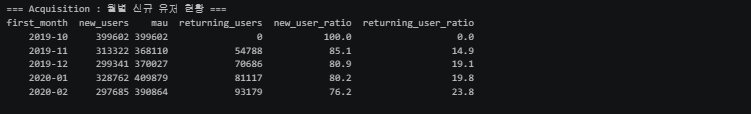

   2. Activation | 활성화 - 퍼널 분석  
   - **전체 유저수 : 1,638,712명 / 구매 유저수 110,499명 / 세션수 4,783,713건** 
   - 'view → cart' 전환율은 23.4%(세션 기준) ~ 24.9%(유저 기준)로 양호한 수준으로 확인된다.   
   - 'cart → purchase' 전환율은 15.0%(세션 기준) ~ 27.8%(유저 기준)으로 개선의 여지가 있다.   
   - 특히 **장바구니에서 삭제(장바구니 이탈)**하는 경우가 **38.2%**로 이 부분에 대하여 추가적으로 원인을 분석해 볼 필요가 있다.   
     (이탈 추정 원인 : 가격, 결제 오류, 타사 유사 기능 제품 존재 등) 

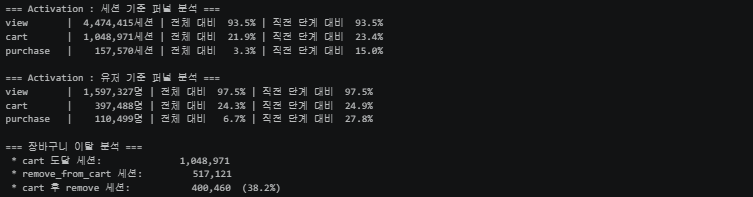

   3. Retention | 유지 - 코호트 분석   
   - 첫 달 이후 이탈율이 86.3%로 대규모 고객이 이탈하는 것을 확인하였다.     
   - 하지만, 이후 감소폭이 줄어들어, 전체 유저 중 약 10%의 핵심 충성고객이 존재하는 것을 파악할 수 있다.  
   - 특히, **구매 경험이 있는 고객**을 대상으로 코호트 분석을 진행하였을 때, 위 패턴이 조금 더 뚜렸하게 나타나는 것을 확인할 수 있다.   
     (2019년 코호트 분석에 있어, 구매 고객의 리텐션이 18.5%로 전체 13.7%보다 높은 것을 확인하였다. '구매' 경험이 서비스를 재사용하는 결정적 이유로 작용하는 것을 확인할 수 있다. 즉, 방문자가 첫 구매까지 행위를 하게 하는 것이 장기적으로 안정화에 영향을 미치는 것을 나타낸다. )

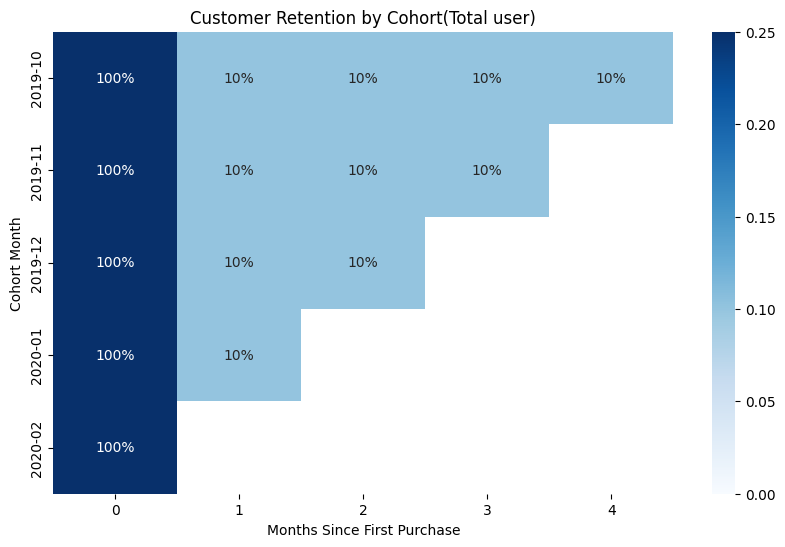

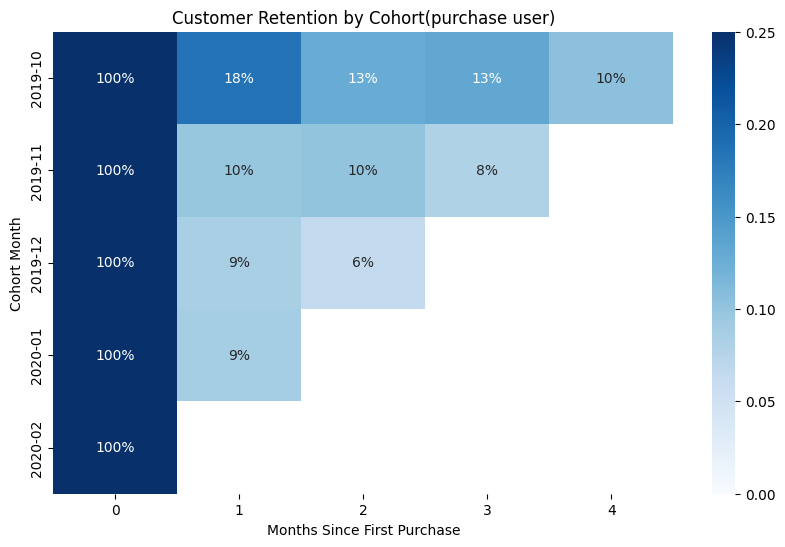

   4. Revenue | 매출 분석    
   - 월별 매출액에 있어, 2019녀 11월 매출이 1,531,350.92$ (구매건수 322,380건)로 가장 높은 것으로 나타났다. 블랙프라이데이 효과로 추정할 수 있다.   
   - 1회 구매한 유저는 11,416명(10.%)이고, 2회 이상 구매한 유저수는 99,083명(89.7)로 재구매율이 높은 것을 확인할 수 있었다.  
   - 화장품 시장의 특성 상, 특히 기초 단계의 제품의 경우 구매자 개인의 피부 타입 등에 맞는 제품을 구입하며, 제품의 효과를 체험한 고객의 경우 재구매로 이러지는 것과 연결되는 결과라고 볼 수 있다.   
   - 해당 데이터셋의 경우, product_id만 존재하며, 해당 제품이 기초군인지, 색조군인지 구분되어 있지 않다. 기초 제품군인지, 색조 제품인지 구분이 되어 있다면, 제품군에 따른 고객의 유입형태 분석이 가능할 것으로 예상된다. (색조 제품의 경우, 피부 특성과는 무관하게 신규 고객이 유입될 요소가 충분하다.)
   - 화장품 시장의 주된 수익원은 신규 유저가 아닌 이미 구매 경험이 있는 '기존 고객'임을 알 수 있다.  

   5. Referral | 추천  
   - 신규 고객의 수가 감소하는 것을 Acquisition 분석을 통해 확인하였다. 추천코드와 같이 '추천'과 관련된 데이터셋이 존재하지 않아 특징을 확인하지 못하였다. 

## Ⅳ. 비즈니스 제언  

   1. **첫 구매 후 이탈 방지 방안 (Acquisition)**  
   - 첫 구매 후 7일 이내 : 구매 만족도(배송기간, 포장상태, 사용 후기 등) 작성시 포인트 부여  
   - 첫 구매 후 1개월 이내 : 1달 간 구매후기(사용법, 사용전후 후기 등) 작성시 추가 포인트 부여  
   - 할인 쿠폰 발송 및 관련 상품 추천 : 제품 사용 주기를 반영하여 1달 주기로 할인 쿠폰을 발송하며, 더불어 고객 정보에 기재된 피부고민과 연관지어 'A제품을 구입한 고객님께서 B 제품도 구입하셨어요' 등과 같이 제품을 추천하여, 제품에 대한 관심을 유도(view → cart)한다.  

   2. **장바구니 이탈 개선 (Activation)**  
   - 제품 샘플 제공 및 반품/환불 절차 개선 : 화장품 구매에 있어서 구매를 망설이게 하는 요인이 사용 후 문제 발생일 것이다. 제품에 대하여 관심이 있지만 막상 구매하는 데 주저하게 되는 것이 다른 이들에게는 효과가 있지만 정작 사용자 본인에게 문제가 생길 수 있다는 두려움이 구매를 주저하게 만든다. 이와 관련하여 제품의 샘플을 제공하여, 본품 사용 전 샘플 사용 후 미개봉 제품에 대하여 환불이 가능하도록 절차를 개선한다.  
   - 장바구니 리마인드 알림, 할인 쿠폰 발송 및 관련 이벤트 안내 : sns 등 광고를 통해 사이트에 접속 후, 해당 제품을 장바구니에 담아놓을 경우, 첫 신규 가입 쿠폰(사용기간 제한)을 제공하며, 이후 구매로 연결되지 않을 경우, 장바구니에 제품이 있다는 알림과 함께 일정 기간이 지나면 한정 쿠폰이 사라진다는 안내를 진행한다. 신규 가입 후 1달 이상 제품을 구입하지 않은 경우, 이후 해당 상품에 이벤트를 진행할 경우, 관심 제품에 대한 할인이 진행된다는 알림을 발송한다.  
     
   3. **재구매 고객층 확보 (Retenrion)**  
   - 고객 등급화 : 구매 수와 가격을 기준으로 고객을 등급화하여 이들에 대한 구매 패턴, 선호 상품(자주 구매하는 상품), 구매 주기를 분석한다.   
   - 멤버십 등급제 : 등급별 할인율, 추후 사용할 수 있는 적립금 혜택(등급별 차등 적립율), 제품 구매시 샘플 제공(등급별 제공 개수 차등), 추가 업체 진행 이벤트(메이크업 클래스 등) 참여권 제공  
   - 친구 초대시 적립금 지급

   4. 매출 증대 전략 (Revenue)  
   - 장기 고객화 전략 : 시즌 이벤트를 통해 일시적으로 유입된 고객이 재구매 할 수 있도록, Activation 전략을 같이 진행한다.  
   - 화장품 구독 서비스 : 재구매 고객층을 대상으로 사용 제품유형을 파악하여, 꾸준히 사용하는 제품에 대하여 정기구독 서비스를 제공한다. 정기 구독시 정가 대비 금액할인, 추가 샘플 증정 등 혜택을 제공하여, 안정적인 매출을 확보한다.   

---
### **[Step. 0]** 데이터 불러오기 및 합치기

- 각 월별로 구분되어 있는 5개월간의 고객 데이터를 고객 행동 패턴을 파악하기 위하여 하나로 합치고 추가로 '월'을 분류할 수 있는 컬럼을 생성한다.  
- 해당 데이터의 기본 구조 및 결측치를 파악한다. 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
files = {
    'oct2019' : '2019-Oct.csv',
    'nov2019' : '2019-Nov.csv',
    'dec2019' : '2019-Dec.csv',
    'jan2020' : '2020-Jan.csv',
    'feb2020' : '2020-Feb.csv'
}

dfs =[]
for month, fname in files.items():
    df = pd.read_csv(fname)
    df['month'] = month # 월 구분 컬럼 추가
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print(f"[STEP 0] 원본 데이터 : {len(df):,}행 / {df.shape[1]}개 컬럼")
print(f"         컬럼 목록 : {list(df.columns)}")


[STEP 0] 원본 데이터 : 20,692,840행 / 10개 컬럼
         컬럼 목록 : ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session', 'month']


---
#### 데이터 기본 정보 확인

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20692840 entries, 0 to 20692839
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
 9   month          object 
dtypes: float64(1), int64(3), object(6)
memory usage: 1.5+ GB


In [4]:
# event_time의 dtype 변환 : object -> datetime
df['event_time'] = pd.to_datetime(df['event_time'], utc=True )

# year_month 컬럼 추가
df['year_month'] = df['event_time'].dt.to_period('M')

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_42448\2327593600.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['event_time'].dt.to_period('M')


In [5]:
# 기본 데이터 형태 확인 : 총 20,692,840건의 event 발생
print("Dataset shape:", df.shape)
print("Dataset dtypes:", df.dtypes)
print(df.head())

Dataset shape: (20692840, 11)
Dataset dtypes: event_time       datetime64[ns, UTC]
event_type                    object
product_id                     int64
category_id                    int64
category_code                 object
brand                         object
price                        float64
user_id                        int64
user_session                  object
month                         object
year_month                 period[M]
dtype: object
                 event_time event_type  product_id          category_id  \
0 2019-10-01 00:00:00+00:00       cart     5773203  1487580005134238553   
1 2019-10-01 00:00:03+00:00       cart     5773353  1487580005134238553   
2 2019-10-01 00:00:07+00:00       cart     5881589  2151191071051219817   
3 2019-10-01 00:00:07+00:00       cart     5723490  1487580005134238553   
4 2019-10-01 00:00:15+00:00       cart     5881449  1487580013522845895   

  category_code   brand  price    user_id  \
0           NaN  runail   2.62  46324

In [6]:
# 월별 이벤트 수 : 2019년 11월과 2020년 01월의 고객 활동(event)이 두드러짐  -> 시즌 영향이 있는 지 여부 추가 확인 

print("\n=== 월별 이벤트 수 ===")
print(df.groupby('month')['event_type'].count())


=== 월별 이벤트 수 ===
month
dec2019    3533286
feb2020    4156682
jan2020    4264752
nov2019    4635837
oct2019    4102283
Name: event_type, dtype: int64


---
### **[Step. 1]** EDA  
#### 결측치 확인 및 주요 컬럼 고유값 확인

In [7]:
# 결측치 확인
print("\n=== 결측치 현황(개수) ===")
print(df.isnull().sum())
print()
print("\n=== 결측치 현황(비율) ===")
print(df.isnull().mean().round(4) * 100, "(%)")


=== 결측치 현황(개수) ===
event_time              0
event_type              0
product_id              0
category_id             0
category_code    20339246
brand             8757117
price                   0
user_id                 0
user_session         4598
month                   0
year_month              0
dtype: int64


=== 결측치 현황(비율) ===
event_time        0.00
event_type        0.00
product_id        0.00
category_id       0.00
category_code    98.29
brand            42.32
price             0.00
user_id           0.00
user_session      0.02
month             0.00
year_month        0.00
dtype: float64 (%)


In [8]:
# 고유값 확인
for col in ['event_time', 'user_id', 'product_id', 'user_session', 'brand', 'category_id', 'category_code']:
    print(f"* {col} 고유값 수: {df[col].nunique():,}")

# 전체 행(row) 20,692,840개와 'event_time'고유값 8,782,890건 비교
# 동일한 시점에 여러 개의 이벤트 발생 (약 2.356건) 
# => 여러 유저가 동시에 행동을 하거나 또는 한명의 유저가 여러 개의 이벤트를 발생

* event_time 고유값 수: 8,782,890
* user_id 고유값 수: 1,639,358
* product_id 고유값 수: 54,571
* user_session 고유값 수: 4,535,941
* brand 고유값 수: 273
* category_id 고유값 수: 525
* category_code 고유값 수: 12


---
#### **event_type**
 : 고객행동 type 구분 - 장바구니 추가(cart), 상품확인(view), 장바구니제거(remove_from_cart), 구매(purchase)

In [9]:
# event_type 확인  
df['event_type'].unique()

array(['cart', 'view', 'remove_from_cart', 'purchase'], dtype=object)

In [10]:
# event_type 분포 및 비율 : 
print("\n=== event_type 분포 ===")
print(df['event_type'].value_counts())
print()
print("\n=== event_type 분포(비율) ===")
print(df['event_type'].value_counts(normalize=True).round(3))


=== event_type 분포 ===
event_type
view                9657821
cart                5768333
remove_from_cart    3979679
purchase            1287007
Name: count, dtype: int64


=== event_type 분포(비율) ===
event_type
view                0.467
cart                0.279
remove_from_cart    0.192
purchase            0.062
Name: proportion, dtype: float64


---
#### **price** 
: 평균 8.534735 / 중앙겂 4.05 / **최솟값 -79.37 (취소 또는 이상치)** / 최댓값 327.78

In [11]:
# 가격 기본 통계 

print("\n=== 가격 기초통계 ===")
print(df['price'].describe())


=== 가격 기초통계 ===
count    2.069284e+07
mean     8.534735e+00
std      1.938142e+01
min     -7.937000e+01
25%      2.060000e+00
50%      4.050000e+00
75%      7.060000e+00
max      3.277800e+02
Name: price, dtype: float64


---
* 음수 price 확인 : 전체 데이터 중 131건에 있어 price 값이 음수로 확인  

- event_type = purchase (126건) : 이전 구매내역이 존재하면, "환불", 이전 구매내역이 없다면, "오류"  
- event_type = remove_from_cart (3건) : 장바구니에서 삭제한 내역에 있어 price가 음수는 "오류"로 보는 것이 타당함 => 삭제  
- event_type = view (2건) : 확인한 제품의 가격이 (-)인 것은 "오류"로 보는 것이 타당함 => 삭제


In [12]:

negative_price = df[df['price'] < 0]
print(f"* 음수 price 건수: {len(negative_price):,}")
print(f"\n* 음수 price의 event_type 분포:")
print(negative_price['event_type'].value_counts())


* 음수 price 건수: 131

* 음수 price의 event_type 분포:
event_type
purchase            126
remove_from_cart      3
view                  2
Name: count, dtype: int64


In [13]:
# 음수 price 가격 통계 : 평균 -30.7163 / min -79.37 / max -7.94

print(f"\n* 음수 price 기초통계:")
print(negative_price['price'].describe())


* 음수 price 기초통계:
count    131.000000
mean     -30.716336
std       20.352656
min      -79.370000
25%      -47.620000
50%      -23.810000
75%      -15.870000
max       -7.940000
Name: price, dtype: float64


In [14]:
# 음수 price 값의 데이터 중 event_type == "purchase" 항목의 이전 구매내역 확인
# 동일한 user에 있어, 동인할 product_id에 대한 purchase(+ 값) 내용이 존재하는 지 확인
# => 기존 구매내역에 대한 "취소" 건으로 볼 수 있음

# 음수 purchase 행 추출
neg_purchase = df[
    (df['event_type'] == 'purchase') & (df['price'] < 0)
].copy()

print(f"* 음수 purchase 건수: {len(neg_purchase)}")
print(f"* 관련 유저 수: {neg_purchase['user_id'].nunique()}")
print(f"* 관련 상품 수: {neg_purchase['product_id'].nunique()}")
print(f"* 관련 상품 목록 : {negative_price['product_id'].value_counts().head(10)}")

* 음수 purchase 건수: 126
* 관련 유저 수: 108
* 관련 상품 수: 5
* 관련 상품 목록 : product_id
5670257    39
5716857    37
5716859    31
5716855    12
5716861    12
Name: count, dtype: int64


In [15]:
# 정상 purchase (양수) 데이터
pos_purchase = df[
    (df['event_type'] == 'purchase') & (df['price'] > 0)
]

# 음수 purchase 유저+상품 조합
neg_keys = neg_purchase[['user_id', 'product_id']].drop_duplicates()

# 이전 구매 내역 존재 여부 확인
#   → 동일 user_id + product_id로 양수 purchase가 있는지 매칭
has_prior_purchase = neg_keys.merge(
    pos_purchase[['user_id', 'product_id']].drop_duplicates(),
    on=['user_id', 'product_id'],
    how='left',
    indicator=True
)

confirmed_refund = has_prior_purchase[
    has_prior_purchase['_merge'] == 'both'
]
no_prior = has_prior_purchase[
    has_prior_purchase['_merge'] == 'left_only'
]

print(f"\n✅ 이전 구매 내역 있음 (환불 확정): "
      f"{len(confirmed_refund)}건")
print(f"❌ 이전 구매 내역 없음 (오류 추정): "
      f"{len(no_prior)}건")


✅ 이전 구매 내역 있음 (환불 확정): 0건
❌ 이전 구매 내역 없음 (오류 추정): 114건


In [16]:
# 음수 purchase에 발생 시간 포함
neg_with_time = neg_purchase[
    ['user_id', 'product_id', 'event_time', 'price']
].copy()
neg_with_time.columns = [
    'user_id', 'product_id', 'neg_time', 'neg_price'
]

# 양수 purchase에 발생 시간 포함
pos_with_time = pos_purchase[
    ['user_id', 'product_id', 'event_time', 'price']
].copy()
pos_with_time.columns = [
    'user_id', 'product_id', 'pos_time', 'pos_price'
]

# 동일 유저+상품 기준으로 병합
time_check = neg_with_time.merge(
    pos_with_time,
    on=['user_id', 'product_id'],
    how='left'
)

# 환불 시점이 구매 시점보다 이후인 경우만 진짜 환불
time_check['is_valid_refund'] = (
    time_check['neg_time'] > time_check['pos_time']
)

valid_refund = time_check[time_check['is_valid_refund'] == True]
invalid = time_check[time_check['is_valid_refund'] != True]

print(f"✅ 시간 순서 검증 통과 (진짜 환불): "
      f"{valid_refund['user_id'].nunique()}명 / "
      f"{len(valid_refund)}건")
print(f"❌ 시간 순서 불일치 또는 매칭 실패: "
      f"{len(invalid)}건")

✅ 시간 순서 검증 통과 (진짜 환불): 0명 / 0건
❌ 시간 순서 불일치 또는 매칭 실패: 126건


In [17]:
# price 컬럼에 있어 (-)인 데이터 제거 후 df 저장 : 131건 제거
# : 위 결과에 따라 해당 데이터를 환불 처리된 내역으로 볼 수 없으며, '오류'로 판단되어 해당 데이터 제거 진행

df = df[df['price'] >= 0]
print(f"\n* price (-)인 데이터 제거 후 데이터 크기 : {len(df):,}행") 


* price (-)인 데이터 제거 후 데이터 크기 : 20,692,709행


---
#### **User_Session**  
: 한 명의 유저가 웹사이트 또는 앱에 접속하여 이탈할 때까지 하나의 방문 단위

In [18]:
# 전체 행(row) 20,692,840개와 'user_session'고유값 4,535,941건 비교 
# (* 당초 고유값 확인에 있어서 4,535,941 이었으나, price 음수 데이터를 삭제하여 고유값 개수에 변동 발생.)
# 유저가 사이트 또는 앱에 접속하여 이탈하는 하나의 세션(session) 단위에서 여러 행동(event) 발생 :약 4.562 event/session 

df['user_session'].nunique() # 고객이 접속후 이탈을 하나의 세션으로 보았을 때, 5개월간 session의 개수 : 4,535,940

4535940

* 결측치 현황 재확인

In [19]:
print(f"* user_session 결측치 수: {df['user_session'].isnull().sum():,}")
print(f"* 결측치 비율: {df['user_session'].isnull().mean()*100:.3f}%")

# 결측치 행의 event_type 분포 확인
print("\n* 결측치 행의 event_type 분포:")
print(df[df['user_session'].isnull()]['event_type'].value_counts())

# 결측치 행의 user_id 고유 수
print(f"\n* 결측치 행의 user_id 수: "
      f"{df[df['user_session'].isnull()]['user_id'].nunique():,}")

* user_session 결측치 수: 4,598
* 결측치 비율: 0.022%

* 결측치 행의 event_type 분포:
event_type
cart                3776
remove_from_cart     791
view                  31
Name: count, dtype: int64

* 결측치 행의 user_id 수: 1,533


In [20]:
# 결측치 제거 : 전체 데이터 20,692,840건 중 4,598건(0.022%)로 매우 작은 비중을 차지함 => 세션 분석시 신뢰성을 위해 '삭제'
before = len(df)
df = df[df['user_session'].notnull()].copy()
after = len(df)

print(f"* user_session 결측치 제거 전: {before:,}행")
print(f"* user_session 결측치 제거 후: {after:,}행")
print(f"* 제거된 행(결측치 개수): {before - after:,}행")

* user_session 결측치 제거 전: 20,692,709행
* user_session 결측치 제거 후: 20,688,111행
* 제거된 행(결측치 개수): 4,598행


In [21]:
# 동일 session에서 발생한 event_type 확인

session_events = df.groupby('user_session')['event_type'].apply(list)
print(session_events.head(10))

user_session
0000061d-f3e9-484b-8c73-e54f355032a3                                               [view]
00000ac8-0015-4f12-996a-be2896323738                                               [view]
00000dd2-0f5d-4fc9-9d6b-2fc8c7514b04                                               [view]
000013d6-68a4-40cf-9452-6577dbfab515    [view, view, cart, remove_from_cart, remove_fr...
00001aa1-7ee6-4d8c-81ff-bd5ce1dd1d6e                                         [view, view]
00001bc6-1e04-4861-be5d-1bc73929c21a                                               [view]
00001ca1-f2df-4572-b0b8-e752e2064aae                                               [view]
00001e77-5db8-4e96-ab7a-022ed3caf8b3                                               [view]
000027d7-5077-4a81-89de-ce2c4936a28f                                               [view]
00002b0e-d7f7-454e-8386-431c4021a9f6    [remove_from_cart, cart, cart, cart, cart, car...
Name: event_type, dtype: object


* Session 정의 신뢰성 확인   
: 1개의 session이 여러 user_id를 가지는 경우가 있는지 확인 (이상치 확인)

In [22]:
session_user_count = df.groupby('user_session')['user_id'].nunique()
print("* 세션당 user_id 수 분포:")
print(session_user_count.value_counts())

* 세션당 user_id 수 분포:
user_id
1    4535668
2        241
3         17
4          7
5          4
7          2
8          1
Name: count, dtype: int64


In [23]:
# 이상 세션 목록 추출 : 1개의 세션에 2개 이상의 user_id가 있는 경우 : 272건 오류 확인

abnormal_sessions = session_user_count[session_user_count > 1].index
abnormal_sessions

print(f"* 이상 세션 수: {len(abnormal_sessions)}")
print(f"* 이상 세션으로 인한 제거 row 수: "
      f"{df[df['user_session'].isin(abnormal_sessions)].shape[0]:,}")

* 이상 세션 수: 272
* 이상 세션으로 인한 제거 row 수: 1,985


In [24]:
# 이상 세션 (1개의 세션에 2개 이상의 user_id 존재) 제거
df = df[~df['user_session'].isin(abnormal_sessions)]
print(f"* 이상 세션 제거 후: {len(df):,}행")

* 이상 세션 제거 후: 20,686,126행


---
* session 지속 시간 범위 확인   
: 평균 256.898분 / 최소 0분 / 최대 218,325.9분(3,638시간 / 152일 / 5개월)

In [25]:
session_duration = df.groupby('user_session')['event_time'].agg(
    session_start='min',
    session_end='max'
)
session_duration['duration_min'] = (
    session_duration['session_end'] - session_duration['session_start']
).dt.total_seconds() / 60
print("\n세션 지속 시간 통계 (분):")
print(session_duration['duration_min'].describe())


세션 지속 시간 통계 (분):
count    4.535668e+06
mean     2.568205e+02
std      5.153472e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.550000e+00
max      2.183259e+05
Name: duration_min, dtype: float64


In [26]:
# 최대 세션 지속 시간 데이터 확인
session_duration[session_duration['duration_min'] == 218325.93333333332]

,session_start,session_end,duration_min
user_session,,,
ae74cec4-ae31-4470-8484-84c3a75365d3,2019-10-01 05:48:54+00:00,2020-02-29 20:34:50+00:00,218325.933333


In [27]:
# 최대 세션 지속 시간 user_id 및 구매주기 확인 : user_id 341557108 / 매월 event 발생
df[df['user_session'] == 'ae74cec4-ae31-4470-8484-84c3a75365d3']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month,year_month
11076,2019-10-01 05:48:54+00:00,view,9813,1487580012717539489,NaN,NaN,7.14,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,oct2019,2019-10
131656,2019-10-01 21:12:17+00:00,view,5682468,1487580007910867929,NaN,zinger,19.21,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,oct2019,2019-10
328776,2019-10-02 20:58:19+00:00,view,5700035,1487580009286598681,NaN,runail,0.40,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,oct2019,2019-10
328912,2019-10-02 20:59:11+00:00,cart,5786834,1783999068909863670,NaN,smart,4.76,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,oct2019,2019-10
328971,2019-10-02 20:59:38+00:00,cart,5786835,1783999068909863670,NaN,smart,4.76,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,oct2019,2019-10
...,...,...,...,...,...,...,...,...,...,...,...
20677180,2020-02-29 20:30:49+00:00,view,5692864,1487580007910867929,NaN,yoko,7.29,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,feb2020,2020-02
20677258,2020-02-29 20:31:25+00:00,view,5692863,1487580007910867929,NaN,yoko,7.83,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,feb2020,2020-02
20677353,2020-02-29 20:32:13+00:00,view,5692863,1487580007910867929,NaN,yoko,7.83,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,feb2020,2020-02
20677473,2020-02-29 20:33:15+00:00,view,5650457,1487580007910867929,NaN,metzger,6.83,341557108,ae74cec4-ae31-4470-8484-84c3a75365d3,feb2020,2020-02


---
* 장기 session 분리  
: 앞선 user_session 지속 시간 범위 검토에 있어, 평균 256.898분, 최대 218,325.9분(3,638시간 / 152일 / 5개월)인 사항을 확인하였다.   사실상 다수의 독립 세션으로 구분하는 것이 타당하다. 업계에서 통용되는 기준인, 이벤트 간격이 30분 초과하는 경우, 새 세션으로 분리하는 작업을 진행한다. 

In [28]:
# 세션 지속 시간이 30분 초과인 데이터개수 확인

long_session_duration = session_duration[session_duration['duration_min'] > 30]
print(f"* 세션 지속시간 30분 초과 데이터 건수: {len(long_session_duration):,}")
print(f"\n* 30분 초과 session 기초통계:")
print(long_session_duration['duration_min'].describe())

* 세션 지속시간 30분 초과 데이터 건수: 288,475

* 30분 초과 session 기초통계:
count    288475.000000
mean       4010.473059
std       20063.087494
min          30.016667
25%          44.716667
50%          77.800000
75%         246.600000
max      218325.933333
Name: duration_min, dtype: float64


In [29]:
# 세션 재정의
df = df.sort_values(['user_id', 'user_session', 'event_time'])

# 동일 user_session 내 이전 이벤트와의 시간 간격 계산
df['prev_event_time'] = df.groupby(['user_id', 'user_session'])['event_time'].shift(1)
df['time_gap_min'] = (
    df['event_time'] - df['prev_event_time']
).dt.total_seconds() / 60

# 이벤트 간격이 30분 초과일 경우, 새 세션 시작으로 표시
df['new_session_flag'] = (
    df['time_gap_min'] > 30
) | (df['prev_event_time'].isnull())  # 세션의 첫 이벤트

# 세션 내 누적 분리 횟수로 새 세션 ID 생성
df['session_split_num'] = df.groupby(
    ['user_id', 'user_session']
)['new_session_flag'].cumsum().astype(int)

# 최종 새 세션 ID = 기존 session + 분리번호
df['clean_session'] = (
    df['user_session'].astype(str) + '_' +
    df['session_split_num'].astype(str)
)

# 임시 컬럼 정리
df = df.drop(columns=['prev_event_time', 'time_gap_min',
                       'new_session_flag', 'session_split_num'])

print(f"* 원래 세션 수: {df['user_session'].nunique():,}")
print(f"* 재정의 후 세션 수: {df['clean_session'].nunique():,}")

* 원래 세션 수: 4,535,668
* 재정의 후 세션 수: 4,809,954


---
*  유저당 세션수 확인   
: 1명의 user_id가 여러 session을 가지는지 여부을 확인하여 "재방문 유저" 확인  
(결과) user_session 기준 : user_id 고유값 1,638,714명 / 1명당 평균 세션 수 2.768 건 / min 1건 / Max 17,403건  
          clean_session 기준 : user_id 고유값 1,638,714명 / 1명당 평균 세션 수 2.935 건 / min 1건 / Max 17,421건  

In [30]:
user_session_count = df.groupby('user_id')['user_session'].nunique()
print("* 유저당 세션 수 분포:")
print(user_session_count.describe())

* 유저당 세션 수 분포:
count    1.638714e+06
mean     2.767822e+00
std      2.007780e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.740300e+04
Name: user_session, dtype: float64


In [31]:
clean_session_count = df.groupby('user_id')['clean_session'].nunique()
print("* 유저당 재정의 세션 수분포:")
print(clean_session_count.describe())

* 유저당 재정의 세션 수분포:
count    1.638714e+06
mean     2.935200e+00
std      2.074267e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.742100e+04
Name: clean_session, dtype: float64


* 유저당 세션수에 대한 추가 확인  
 : 앞서 유저당 세션수 분포에 있어서 Max 17,403건(30분 기준 재정의한 세션(clean_session) 기준 17,421건)에 대해 의문점을 발견하였다.   
   한 명의 유저가 30분 단위로 쉬지 않고, 5개월(152일)간 접속한다고 가정하였을 경우, 최대 발생할 수 있는 세션의 수는 7,296건(= 24시간 * 2회 * 152일)이다. 7,296건이 넘는 user_id에 있어서 한 개인의 id를 여러 명이 공유하여 여러 사람이 사용한다면 17,403과 같은 수치가 나올 수 있으나, 유저별 특징을 분석하는 데 적합하지 않은 것으로 판단된다.   
   이에 이상 유저(user_id당 세션수 7,296건을 초과하는 경우)를 파악하고, 분석 데이터에서 삭제하도록 한다.


In [32]:
# 재정의 세션 기준 유저당 세션 수
clean_session_count = df.groupby('user_id')['clean_session'].nunique()

# 분포 구간별 확인
print("=== 세션 수 구간별 유저 분포 ===")
bins = [0, 10, 50, 100, 500, 1000, 5000, 10000, 20000]
labels = ['1-10', '11-50', '51-100', '101-500',
          '501-1000', '1001-5000', '5001-10000', '10001+']
distribution = pd.cut(clean_session_count,
                       bins=bins, labels=labels).value_counts().sort_index()
print(distribution)

# 이상 유저 임계값 설정 전 상위 확인
print("\n=== 세션 수 상위 10개 유저 ===")
top_users = clean_session_count.sort_values(ascending=False).head(10)
print(top_users)

=== 세션 수 구간별 유저 분포 ===
clean_session
1-10          1576310
11-50           54625
51-100           5196
101-500          2451
501-1000           98
1001-5000          31
5001-10000          2
10001+              1
Name: count, dtype: int64

=== 세션 수 상위 10개 유저 ===
user_id
527021202    17421
557616099     8820
557956487     6019
553753653     3691
500927959     3364
223293700     3033
577763915     2440
597135174     2290
373989853     2241
541975884     2116
Name: clean_session, dtype: int64


In [33]:
# 상위 이상 유저 행동 패턴 상세 확인
top_user_id = clean_session_count.idxmax()
print(f"\n* 최다 세션 유저: {top_user_id}")

top_user_data = df[df['user_id'] == top_user_id].copy()
print(f" - 총 이벤트 수: {len(top_user_data):,}")
print(f" - 총 세션 수: {top_user_data['clean_session'].nunique():,}")
print(f" - event_type 분포:")
print(top_user_data['event_type'].value_counts())
print(f"\n- 월별 이벤트 수:")
print(top_user_data.groupby('year_month').size())
print(f"\n- 일별 평균 세션 수:")

top_user_data['date'] = top_user_data['event_time'].dt.date
daily_sessions = top_user_data.groupby('date')['clean_session'].nunique()
print(daily_sessions.describe())
print(f"\n* 최다 세션 유저의 일별 최대 세션 수: {daily_sessions.max()}")
print(f"* 최다 세션 유저의 일별 평균 세션 수: {daily_sessions.mean():.1f}")


* 최다 세션 유저: 527021202
 - 총 이벤트 수: 26,752
 - 총 세션 수: 17,421
 - event_type 분포:
event_type
view                20492
cart                 4292
remove_from_cart     1968
Name: count, dtype: int64

- 월별 이벤트 수:
year_month
2019-10       66
2019-11    11720
2019-12     8689
2020-01     5416
2020-02      861
Freq: M, dtype: int64

- 일별 평균 세션 수:
count      80.000000
mean      217.775000
std       538.525506
min         1.000000
25%         1.000000
50%         3.000000
75%        17.250000
max      3012.000000
Name: clean_session, dtype: float64

* 최다 세션 유저의 일별 최대 세션 수: 3012
* 최다 세션 유저의 일별 평균 세션 수: 217.8


In [34]:
# session 임계값 설정
# 현실적 최대 세션 수 계산

minutes_per_day = 24 * 60          # 1,440분
session_interval = 30               # 30분 간격
max_sessions_per_day = minutes_per_day / session_interval  # 48건
total_days = 152                    # 5개월
theoretical_max = max_sessions_per_day * total_days  # 7,296건

print(f"이론적 최대 세션 수: {theoretical_max:,.0f}건")

이론적 최대 세션 수: 7,296건


In [35]:
# 이상 유저 제거

# 임계값 = 이론적 최대값(7,296건) 적용

THRESHOLD = int(theoretical_max)  # 7,296

normal_users = clean_session_count[
    clean_session_count <= THRESHOLD
].index
abnormal_users = clean_session_count[
    clean_session_count > THRESHOLD
].index

print(f"=== 임계값: {THRESHOLD}건 ===")
print(f"정상 유저 수:   {len(normal_users):,}명")
print(f"이상 유저 수:   {len(abnormal_users):,}명")
print(f"이상 유저 비율: {len(abnormal_users)/len(clean_session_count)*100:.3f}%")
print(f"\n이상 유저로 인한 제거 행 수:")
print(f"{df[df['user_id'].isin(abnormal_users)].shape[0]:,}행")

# 제거 실행
before = len(df)
df = df[df['user_id'].isin(normal_users)].copy()
after = len(df)

print(f"\n제거 전: {before:,}행")
print(f"제거 후: {after:,}행")
print(f"제거된 행: {before - after:,}행")

=== 임계값: 7296건 ===
정상 유저 수:   1,638,712명
이상 유저 수:   2명
이상 유저 비율: 0.000%

이상 유저로 인한 제거 행 수:
36,655행

제거 전: 20,686,126행
제거 후: 20,649,471행
제거된 행: 36,655행


In [36]:
# 이상치 제거 후 세션 분포 재확인
clean_session_count_v2 = df.groupby('user_id')['clean_session'].nunique()

print("=== 이상치 제거 후 유저당 세션 수 분포 ===")
print(clean_session_count_v2.describe())

print(f"\n이론적 최대값 {THRESHOLD}건 이하 유저만 포함 확인:")
print(f"Max: {clean_session_count_v2.max():,}")

=== 이상치 제거 후 유저당 세션 수 분포 ===
count    1.638712e+06
mean     2.919191e+00
std      1.405986e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      6.019000e+03
Name: clean_session, dtype: float64

이론적 최대값 7296건 이하 유저만 포함 확인:
Max: 6,019


In [44]:
print(f"\n{'='*40}")
print(f"[최종] 클린 데이터 현황")
print(f"{'='*40}")
print(f"전체 행 수:       {len(df):,}")
print(f"컬럼 수:          {df.shape[1]}")
print(f"컬럼 목록:        {list(df.columns)}")
print(f"전체 유저 수:     {df['user_id'].nunique():,}")
print(f"클린 세션 수:     {df['clean_session'].nunique():,}")
print(f"기간:             {df['event_time'].min()} ~ {df['event_time'].max()}")
print(f"\nevent_type 분포:")
print(df['event_type'].value_counts())
print(f"\n결측치 현황:")
print(df.isnull().sum())


[최종] 클린 데이터 현황
전체 행 수:       20,649,471
컬럼 수:          12
컬럼 목록:        ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session', 'month', 'year_month', 'clean_session']
전체 유저 수:     1,638,712
클린 세션 수:     4,783,713
기간:             2019-10-01 00:00:00+00:00 ~ 2020-02-29 23:59:59+00:00

event_type 분포:
event_type
view                9626631
cart                5759512
remove_from_cart    3976565
purchase            1286763
Name: count, dtype: int64

결측치 현황:
event_time              0
event_type              0
product_id              0
category_id             0
category_code    20296313
brand             8726874
price                   0
user_id                 0
user_session            0
month                   0
year_month              0
clean_session           0
dtype: int64


---
### **[Step. 2]** AARRR 프레임 분석  

#### **PART 1**. Acquisition | 신규 유저  

- user_id를 기준으로 첫 등장하는 월을 신규 유저가 해당 서비스에 처음 유입된 시점으로 본다.   
- 매월 해당 서비스를 이용하는 신규 유저수는 월별 전체 유저수 대비 감소하는 추세를 보인다.  
  (2019년 10월 신규 유저 399,602명 대비 2020년 2월 신규 유서 297,685명은 25.5% 감소하였다.)  
- 신규 유저수가 감소하는 반면, 재방문 유저 비율은 꾸준히 증가하고 있는 추세를 보인다.   
- 월별 총 유저수(mau)에 있어서, 2020년 1월의 사용자수가 가장 많은 것으로 확인된다. 신년 세일 등 시즌 효과로 추정할 수 있다.   
- 위 내용을 바탕으로 해당 화장품 e커머스 사업이 시장 도입단계가 아닌 '유지' 단계로 전환하고 있음을 추정할 수 있다.     


In [52]:
# ── 월별 신규 유저 집계 ──────────────────────────────
# 유저의 첫 등장 월 = 신규 유저 획득 시점
first_seen = df.groupby('user_id')['year_month'].min().reset_index()
first_seen.columns = ['user_id', 'first_month']

# 월별 신규 유저 수
new_users_monthly = first_seen.groupby(
    'first_month'
).size().reset_index(name='new_users')

# 월별 전체 활성 유저 수 (MAU : Monthly Activation Users)
mau_monthly = df.groupby('year_month')['user_id'].nunique().reset_index(
    name='mau'
)

# 합치기
acquisition = new_users_monthly.merge(
    mau_monthly,
    left_on='first_month',
    right_on='year_month'
).drop(columns='year_month')

acquisition['returning_users'] = (
    acquisition['mau'] - acquisition['new_users']
)
acquisition['new_user_ratio'] = (
    acquisition['new_users'] / acquisition['mau'] * 100
).round(1)

acquisition['returning_user_ratio'] = (
    acquisition['returning_users'] / acquisition['mau'] * 100
).round(1)

print("=== Acquisition : 월별 신규 유저 현황 ===")
print(acquisition.to_string(index=False))

=== Acquisition : 월별 신규 유저 현황 ===
first_month  new_users    mau  returning_users  new_user_ratio  returning_user_ratio
    2019-10     399602 399602                0           100.0                   0.0
    2019-11     313322 368110            54788            85.1                  14.9
    2019-12     299341 370027            70686            80.9                  19.1
    2020-01     328762 409879            81117            80.2                  19.8
    2020-02     297685 390864            93179            76.2                  23.8


---
#### **PART 2**. Activation | 퍼널 분석  

- user_id를 기준으로 'event_type'을 분석하여, 사용자가 서비스 내에서 구매에 이르기까지 도달하는 **단계별 유입, 이탈** 현황을 분석한다.  
- 사용자 별의 활동을 다음과 같이 "view', 'view → cart', 'view → cart → purchase', 'view → cart → remove_from_cart' 구분을 하고, 구간별 전환율을 확인한다.  

In [46]:
# 세션 기준 퍼널 
session_events = df.groupby('clean_session')['event_type'].apply(set)

funnel = {
    'view'    : session_events.apply(lambda x: 'view' in x).sum(),
    'cart'    : session_events.apply(lambda x: 'cart' in x).sum(),
    'purchase': session_events.apply(lambda x: 'purchase' in x).sum()
}

total_sessions = df['clean_session'].nunique()

print("=== Activation : 세션 기준 퍼널 분석 ===")
prev = total_sessions
for step, count in funnel.items():
    print(f"{step:10s} | {count:>10,}세션 "
          f"| 전체 대비 {count/total_sessions*100:5.1f}% "
          f"| 직전 단계 대비 {count/prev*100:5.1f}%")
    prev = count

# 유저 기준 퍼널 
print("\n=== Activation : 유저 기준 퍼널 분석 ===")
total_users = df['user_id'].nunique()
user_funnel = {}
prev = total_users
for event in ['view', 'cart', 'purchase']:
    users = df[df['event_type'] == event]['user_id'].nunique()
    user_funnel[event] = users
    print(f"{event:10s} | {users:>10,}명 "
          f"| 전체 대비 {users/total_users*100:5.1f}% "
          f"| 직전 단계 대비 {users/prev*100:5.1f}%")
    prev = users

# remove_from_cart 분석 (이탈 신호) 
cart_sessions = session_events[
    session_events.apply(lambda x: 'cart' in x)
]
remove_sessions = session_events[
    session_events.apply(lambda x: 'remove_from_cart' in x)
]
cart_then_remove = session_events[
    session_events.apply(
        lambda x: 'cart' in x and 'remove_from_cart' in x
    )
]

print(f"\n=== 장바구니 이탈 분석 ===")
print(f" * cart 도달 세션:             {len(cart_sessions):>10,}")
print(f" * remove_from_cart 세션:      {len(remove_sessions):>10,}")
print(f" * cart 후 remove 세션:        {len(cart_then_remove):>10,}  "
      f"({len(cart_then_remove)/len(cart_sessions)*100:.1f}%)")

=== Activation : 세션 기준 퍼널 분석 ===
view       |  4,474,415세션 | 전체 대비  93.5% | 직전 단계 대비  93.5%
cart       |  1,048,971세션 | 전체 대비  21.9% | 직전 단계 대비  23.4%
purchase   |    157,570세션 | 전체 대비   3.3% | 직전 단계 대비  15.0%

=== Activation : 유저 기준 퍼널 분석 ===
view       |  1,597,327명 | 전체 대비  97.5% | 직전 단계 대비  97.5%
cart       |    397,488명 | 전체 대비  24.3% | 직전 단계 대비  24.9%
purchase   |    110,499명 | 전체 대비   6.7% | 직전 단계 대비  27.8%

=== 장바구니 이탈 분석 ===
 * cart 도달 세션:              1,048,971
 * remove_from_cart 세션:         517,121
 * cart 후 remove 세션:           400,460  (38.2%)


---
[Activation 분석 결과]  
- 'view → cart' 전환율은 23.4%(세션 기준) ~ 24.9%(유저 기준)로 양호한 수준으로 확인된다.   
- 'cart → purchase' 전환율은 15.0%(세션 기준) ~ 27.8%(유저 기준)으로 개선의 여지가 있다.   
- 특히 장바구니에서 삭제(장바구니 이탈)하는 경우가 38.2%로 이 부분에 대하여 추가적으로 원인을 분석해 볼 필요가 있다.   
  (이탈 추정 원인 : 가격, 결제 오류, 타사 유사 기능 제품 존재 등)

---
#### **PART 3**. Retention | 월별 코호트 분석   

- 첫 달 이후 이탈율이 86.3%로 대규모 고객이 이탈하는 것을 확인하였다.     
- 하지만, 이후 감소폭이 줄어들어, 전체 유저 중 약 10%의 핵심 충성고객이 존재하는 것을 파악할 수 있다.  
- 특히, 구매 고객을 대상으로 코호트 분석을 진행하였을 때, 위 패턴이 조금 더 뚜렸하게 나타나는 것을 확인할 수 있다. 

In [78]:
# 유저별 신규 가입월 확인

new_df = df.copy()
user_monthly_active = new_df.groupby("user_id")["year_month"].min()
new_df["cohort_month"] = new_df["user_id"].map(user_monthly_active)

# 코호트(첫 등장 월) 붙이기

new_df["cohort_index"] = (
    (new_df["year_month"].dt.year - new_df["cohort_month"].dt.year) * 12
    + (new_df["year_month"].dt.month - new_df["cohort_month"].dt.month)
)

new_df[["user_id","year_month","cohort_month","cohort_index"]].head()

# 코호트 테이블 생성
cohort_data_new_user = new_df.groupby(["cohort_month", "cohort_index"])["user_id"].nunique().reset_index()

cohort_table_new = cohort_data_new_user.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="user_id"
)

print("=== Retention : 월별 코호트 리텐션 ===")
print(cohort_table_new.head())

# 리텐션 피벗
cohort_size_new = cohort_table_new.iloc[:, 0]

retention_new = cohort_table_new.divide(cohort_size, axis=0)

print(f"\n=== Retention : 월별 코호트 리텐션(비율) ===")
print(retention_new.head())

=== Retention : 월별 코호트 리텐션 ===
cohort_index         0        1        2        3        4
cohort_month                                              
2019-10       399602.0  54788.0  36342.0  31744.0  26948.0
2019-11       313322.0  34344.0  21936.0  17420.0      NaN
2019-12       299341.0  27437.0  15606.0      NaN      NaN
2020-01       328762.0  33205.0      NaN      NaN      NaN
2020-02       297685.0      NaN      NaN      NaN      NaN

=== Retention : 월별 코호트 리텐션(비율) ===
cohort_index    0         1         2         3         4
cohort_month                                             
2019-10       1.0  0.137106  0.090945  0.079439  0.067437
2019-11       1.0  0.109612  0.070011  0.055598       NaN
2019-12       1.0  0.091658  0.052135       NaN       NaN
2020-01       1.0  0.101000       NaN       NaN       NaN
2020-02       1.0       NaN       NaN       NaN       NaN


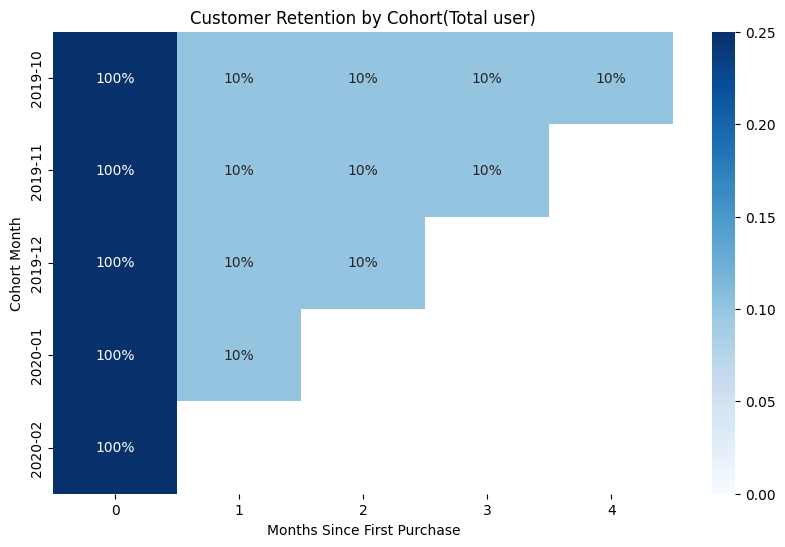

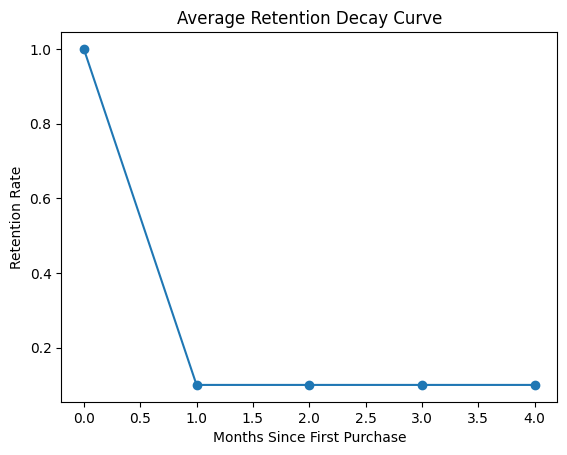

Average Month-1 retention: 10.0 %
Average Month-2 retention: 10.0 %


In [76]:
# 시각화

plt.figure(figsize=(10,6))

sns.heatmap(
    retention_rate,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    vmin=0,
    vmax=0.25
)

plt.title("Customer Retention by Cohort(Total user)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

retention_rate.mean().plot(marker="o")

plt.title("Average Retention Decay Curve")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention Rate")

plt.show()

month1_retention = retention_rate.iloc[:,1].mean()
month2_retention = retention_rate.iloc[:,2].mean()

print("Average Month-1 retention:", round(month1_retention*100,4), "%")
print("Average Month-2 retention:", round(month2_retention*100,4), "%")

---
(추가) 구매 유저별 코호트 분석

In [ ]:
purchase_df = df[df['event_type'] == 'purchase'].copy()

# 유저별 첫 구매월 확인
first_purchase = purchase_df.groupby("user_id")["year_month"].min()
purchase_df["cohort_month"] = purchase_df["user_id"].map(first_purchase)

# 코호트(첫 등장 월) 붙이기

purchase_df["cohort_index"] = (
    (purchase_df["year_month"].dt.year - purchase_df["cohort_month"].dt.year) * 12
    + (purchase_df["year_month"].dt.month - purchase_df["cohort_month"].dt.month)
)

purchase_df[["user_id","year_month","cohort_month","cohort_index"]].head()

,user_id,year_month,cohort_month,cohort_index
7731120,9794320,2019-11,2019-11,0
7731123,9794320,2019-11,2019-11,0
7731125,9794320,2019-11,2019-11,0
7731126,9794320,2019-11,2019-11,0
4800326,10079204,2019-11,2019-11,0


In [79]:
# 코호트 테이블 생성 (구매이력이 있는 활성 유저 대상)
cohort_data = purchase_df.groupby(["cohort_month", "cohort_index"])["user_id"].nunique().reset_index()

cohort_table = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="user_id"
)

print(f"\n=== Retention : 구매 고객 대상 월별 코호트 리텐션 ===")
print(cohort_table.head())

# 코호트 비율

cohort_size = cohort_table.iloc[:, 0]
retention = cohort_table.divide(cohort_size, axis=0)
retention.head()

print(f"\n=== Retention : 구매 고객 대상 월별 코호트 리텐션(비율) ===")
print(retention.head())


=== Retention : 구매 고객 대상 월별 코호트 리텐션 ===
cohort_index        0       1       2       3       4
cohort_month                                         
2019-10       25759.0  4762.0  3292.0  3399.0  2692.0
2019-11       26758.0  2618.0  2716.0  2119.0     NaN
2019-12       19701.0  1678.0  1271.0     NaN     NaN
2020-01       20422.0  1810.0     NaN     NaN     NaN
2020-02       17859.0     NaN     NaN     NaN     NaN

=== Retention : 구매 고객 대상 월별 코호트 리텐션(비율) ===
cohort_index    0         1         2         3         4
cohort_month                                             
2019-10       1.0  0.184867  0.127800  0.131954  0.104507
2019-11       1.0  0.097840  0.101502  0.079191       NaN
2019-12       1.0  0.085173  0.064514       NaN       NaN
2020-01       1.0  0.088630       NaN       NaN       NaN
2020-02       1.0       NaN       NaN       NaN       NaN


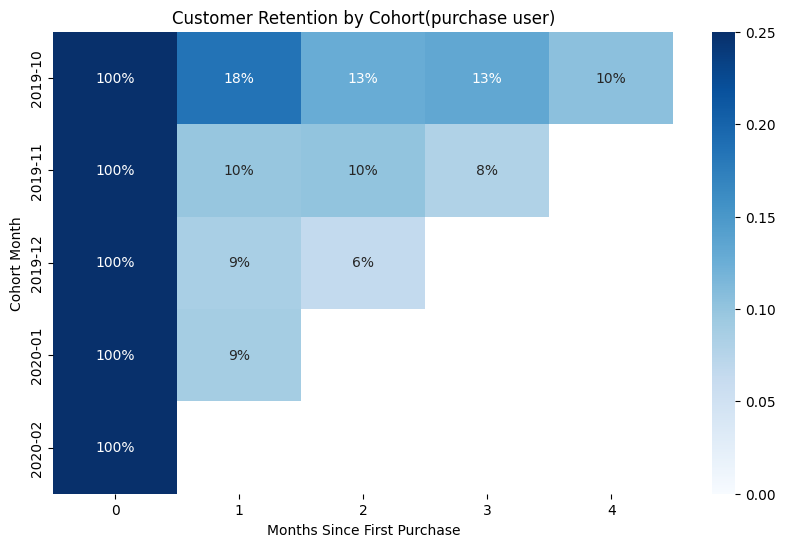

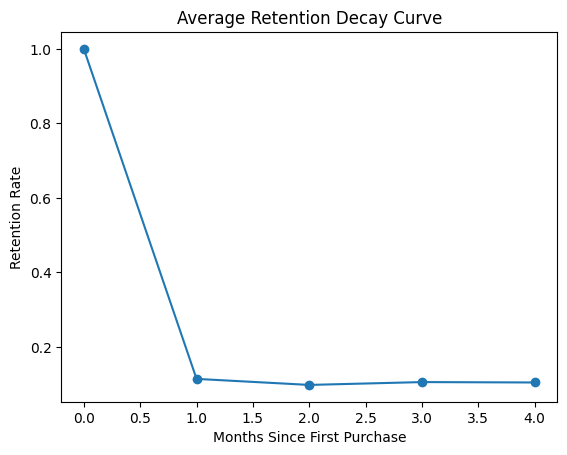

* Average Month-1 retention: 11.41 %
* Average Month-2 retention: 9.79 %


In [85]:
# 시각화(구매 유저 대상)

plt.figure(figsize=(10,6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    vmin=0,
    vmax=0.25
)

plt.title("Customer Retention by Cohort(purchase user)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

retention.mean().plot(marker="o")

plt.title("Average Retention Decay Curve")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention Rate")

plt.show()

month1_retention = retention.iloc[:,1].mean()
month2_retention = retention.iloc[:,2].mean()

print("* Average Month-1 retention:", round(month1_retention*100,2), "%")
print("* Average Month-2 retention:", round(month2_retention*100,2), "%")

---
#### **PART 4**. Revenue | 매출 분석  

- 월 별 총 매출액(월별 price 합계)과 판매수량, 평균 가격, 구매자 수를 확인한다.  
- 유저당 구매액(ARPU)과 구매횟수를 파악한다.  

[Revenue 분석 결과]  
- 월별 매출액에 있어, 2019녀 11월 매출이 1,531,350.92$ (구매건수 322,380건)로 가장 높은 것으로 나타났다. 블랙프라이데이 효과로 추정할 수 있다.   
- 1회 구매한 유저는 11,416명(10.%)이고, 2회 이상 구매한 유저수는 99,083명(89.7)로 재구매율이 높은 것을 확인할 수 있었다.  
- 화장품 시장의 특성 상, 특히 기초 단계의 제품의 경우 구매자 개인의 피부 타입 등에 맞는 제품을 구입하며, 제품의 효과를 체험한 고객의 경우 재구매로 이러지는 것과 연결되는 결과라고 볼 수 있다.   
- 해당 데이터셋의 경우, product_id만 존재하며, 해당 제품이 기초군인지, 색조군인지 구분되어 있지 않다. 기초 제품군인지, 색조 제품인지 구분이 되어 있다면, 제품군에 따른 고객의 유입형태 분석이 가능할 것으로 예상된다. (색조 제품의 경우, 피부 특성과는 무관하게 신규 고객이 유입될 요소가 충분하다.)
- 화장품 시장의 주된 수익원은 신규 유저가 아닌 이미 구매 경험이 있는 '기존 고객'임을 알 수 있다.  


In [ ]:
# ── 월별 매출 요약 ────────────────────────────────────
revenue_monthly = purchase_df.groupby('year_month').agg(
    total_revenue  = ('price', 'sum'),
    purchase_count = ('price', 'count'),
    avg_price      = ('price', 'mean'),
    unique_buyers  = ('user_id', 'nunique')
).round(2)

revenue_monthly['ARPU'] = (
    revenue_monthly['total_revenue'] /
    revenue_monthly['unique_buyers']
).round(2)

# 구매 전환율 (MAU 대비)
revenue_monthly = revenue_monthly.merge(
    mau_monthly.set_index('year_month'),
    left_index=True, right_index=True
)
revenue_monthly['conversion_rate'] = (
    revenue_monthly['unique_buyers'] /
    revenue_monthly['mau'] * 100
).round(2)

print("=== Revenue : 월별 매출 현황 ===")
print(revenue_monthly.to_string())

# ── 구매 횟수 분포 (1회 vs 재구매) ──────────────────
buyer_purchase_count = purchase_df.groupby(
    'user_id'
)['event_type'].count()

print(f"\n=== 구매 횟수 분포 ===")
print(f"1회 구매 유저:  "
      f"{(buyer_purchase_count == 1).sum():,}명 "
      f"({(buyer_purchase_count == 1).mean()*100:.1f}%)")
print(f"2회 이상 구매:  "
      f"{(buyer_purchase_count >= 2).sum():,}명 "
      f"({(buyer_purchase_count >= 2).mean()*100:.1f}%)")
print(f"\n구매 횟수 기초통계:")
print(buyer_purchase_count.describe())

=== Revenue : 월별 매출 현황 ===
            total_revenue  purchase_count  avg_price  unique_buyers   ARPU     mau  conversion_rate
year_month                                                                                         
2019-10        1212003.56          245557       4.94          25759  47.05  399602             6.45
2019-11        1531350.92          322380       4.75          31520  48.58  368110             8.56
2019-12        1078115.36          213153       5.06          25611  42.10  370027             6.92
2020-01        1322557.14          263737       5.01          28215  46.87  409879             6.88
2020-02        1207211.48          241936       4.99          25751  46.88  390864             6.59

=== 구매 횟수 분포 ===
1회 구매 유저:  11,416명 (10.3%)
2회 이상 구매:  99,083명 (89.7%)

구매 횟수 기초통계:
count    110499.000000
mean         11.645019
std          18.266135
min           1.000000
25%           3.000000
50%           6.000000
75%          13.000000
max         715.000000
Name

---
#### **PART 5**. Referral | 추천   

- 신규 사용자 월별 증가율과 특정 제품에 있어서 view수 확인을 통한 간접 추정  
※ 2019년 11월의 경우, 블랙프라이데이가 있음에도 불구하고 신규 유저는 감소하였다. 2020년 1월 신년에 일시적으로 반등이 있었지만, 전반적으로 감소 추세를 확인할 수 있다. 

In [ ]:
# 신규 유저 월별 증가율 (간접 바이럴 신호) 
new_users_monthly_sorted = new_users_monthly.sort_values('first_month')
new_users_monthly_sorted['growth_rate'] = (
    new_users_monthly_sorted['new_users'].pct_change() * 100
).round(1)

print("=== Referral : 신규 유저 월별 증가율 ===")
print(new_users_monthly_sorted.to_string(index=False))

# ── 제품별 view 집중도 (입소문 상품 추정) ──────────────
top_viewed_products = (
    df[df['event_type'] == 'view']
    .groupby('product_id')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
print("\n=== 가장 많이 조회된 상품 Top 10 ===")
print(top_viewed_products)


=== Referral : 신규 유저 월별 증가율 ===
first_month  new_users  growth_rate
    2019-10     399602          NaN
    2019-11     313322        -21.6
    2019-12     299341         -4.5
    2020-01     328762          9.8
    2020-02     297685         -9.5

=== 가장 많이 조회된 상품 Top 10 ===
product_id
5809910    53381
5809912    17779
5751383    15936
5877454    15713
5877456    15147
5751422    14791
5649236    13618
5849033    13327
5856186    13213
5809911    12327
Name: user_id, dtype: int64
